In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV , cross_val_score , train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import warnings
import os

In [4]:
warnings.filterwarnings('ignore')

In [5]:
os.listdir('archive')

['az_cybersecurity_multiclass.csv',
 'az_ecommerce_100k_clean.csv',
 'ev_qiymetleri.csv',
 'heart_disease_15k.csv']

In [6]:
df = pd.read_csv('archive/az_ecommerce_100k_clean.csv')

In [7]:
df.head()

,Yaş,Şəhər,Kateqoriya,Üzvlük_Növü,Ödəniş_Üsulu,Trafik_Mənbəyi,Məbləğ_AZN,Əvvəlki_Alışlar,Müştəri_Rəyi,Saytda_Vaxt_Dəq,Müştəri_ID,Qeydiyyat_Tarixi,Alış_Etdi
0,56.0,Lənkəran,Geyim,Platin,Kart,Sosial Media,130.16,2,5,45.0,AZ000001,2020-01-01,0
1,69.0,Sumqayıt,Mebel,Qızıl,Kart,Birbaşa,82.87,13,4,56.0,AZ000002,2020-01-01,1
2,46.0,Bakı,Elektronika,Gümüş,Kart,Email,NaN,15,4,67.0,AZ000003,2020-01-01,1
3,32.0,Bakı,Ərzaq,Gümüş,Nağd,Sosial Media,103.92,0,4,18.0,AZ000004,2020-01-01,0
4,60.0,Bakı,Kosmetika,Gümüş,Nağd,Sosial Media,11.34,9,3,48.0,AZ000005,2020-01-01,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Yaş               98695 non-null   float64
 1   Şəhər             100500 non-null  object 
 2   Kateqoriya        100500 non-null  object 
 3   Üzvlük_Növü       100500 non-null  object 
 4   Ödəniş_Üsulu      100500 non-null  object 
 5   Trafik_Mənbəyi    100500 non-null  object 
 6   Məbləğ_AZN        98290 non-null   float64
 7   Əvvəlki_Alışlar   100500 non-null  int64  
 8   Müştəri_Rəyi      100500 non-null  int64  
 9   Saytda_Vaxt_Dəq   98988 non-null   float64
 10  Müştəri_ID        100500 non-null  object 
 11  Qeydiyyat_Tarixi  100500 non-null  object 
 12  Alış_Etdi         100500 non-null  int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 10.0+ MB


In [9]:
df.shape

(100500, 13)

In [10]:
df.values

array([[56.0, 'Lənkəran', 'Geyim', ..., 'AZ000001', '2020-01-01', 0],
       [69.0, 'Sumqayıt', 'Mebel', ..., 'AZ000002', '2020-01-01', 1],
       [46.0, 'Bakı', 'Elektronika', ..., 'AZ000003', '2020-01-01', 1],
       ...,
       [48.0, 'Sumqayıt', 'Elektronika', ..., 'AZ088895', '2030-02-20',
        1],
       [59.0, 'Sumqayıt', 'İdman', ..., 'AZ059269', '2026-10-05', 1],
       [36.0, 'Sumqayıt', 'Geyim', ..., 'AZ019663', '2022-03-30', 1]],
      shape=(100500, 13), dtype=object)

In [11]:
df.describe()

,Yaş,Məbləğ_AZN,Əvvəlki_Alışlar,Müştəri_Rəyi,Saytda_Vaxt_Dəq,Alış_Etdi
count,98695.000000,98290.000000,100500.000000,100500.000000,98988.000000,100500.000000
mean,43.505740,98.008004,19.495035,3.869642,45.079838,0.841701
std,14.973071,215.289425,11.519764,1.129701,25.662948,0.365022
min,18.000000,5.000000,0.000000,1.000000,1.000000,0.000000
25%,31.000000,29.400000,10.000000,3.000000,23.000000,1.000000
50%,43.000000,63.610000,19.000000,4.000000,45.000000,1.000000
75%,56.000000,122.800000,29.000000,5.000000,67.000000,1.000000
max,69.000000,6992.033901,39.000000,5.000000,89.000000,1.000000


In [12]:
df.isna().sum()

Yaş                 1805
Şəhər                  0
Kateqoriya             0
Üzvlük_Növü            0
Ödəniş_Üsulu           0
Trafik_Mənbəyi         0
Məbləğ_AZN          2210
Əvvəlki_Alışlar        0
Müştəri_Rəyi           0
Saytda_Vaxt_Dəq     1512
Müştəri_ID             0
Qeydiyyat_Tarixi       0
Alış_Etdi              0
dtype: int64

In [13]:
df.dropna(axis=0 , inplace=True ,ignore_index=True)

In [14]:
df.duplicated().sum()

np.int64(465)

In [15]:
df.drop_duplicates(inplace=True , ignore_index=True)

In [16]:
df.describe(include='object').T

,count,unique,top,freq
Şəhər,94586,10,Bakı,33069
Kateqoriya,94586,8,Geyim,20882
Üzvlük_Növü,94586,4,Standart,47331
Ödəniş_Üsulu,94586,4,Kart,37857
Trafik_Mənbəyi,94586,5,Reklam,28184
Müştəri_ID,94586,94584,AZ012470,2
Qeydiyyat_Tarixi,94586,4167,2031-05-26,24


In [17]:
df['Alış_Etdi'].value_counts()

Alış_Etdi
1    79579
0    15007
Name: count, dtype: int64

In [18]:
df.nunique()

Yaş                    52
Şəhər                  10
Kateqoriya              8
Üzvlük_Növü             4
Ödəniş_Üsulu            4
Trafik_Mənbəyi          5
Məbləğ_AZN          25565
Əvvəlki_Alışlar        40
Müştəri_Rəyi            5
Saytda_Vaxt_Dəq        89
Müştəri_ID          94584
Qeydiyyat_Tarixi     4167
Alış_Etdi               2
dtype: int64

# bu faizini göstərir neçə faiz alınıb neçə faiz yox

In [19]:
df['Alış_Etdi'].value_counts(normalize=True).round(3)

Alış_Etdi
1    0.841
0    0.159
Name: proportion, dtype: float64

In [20]:
df.drop(columns=['Müştəri_ID' , 'Qeydiyyat_Tarixi'] , inplace =True)

In [21]:
df.isna().sum()

Yaş                0
Şəhər              0
Kateqoriya         0
Üzvlük_Növü        0
Ödəniş_Üsulu       0
Trafik_Mənbəyi     0
Məbləğ_AZN         0
Əvvəlki_Alışlar    0
Müştəri_Rəyi       0
Saytda_Vaxt_Dəq    0
Alış_Etdi          0
dtype: int64

# artıq hamsı təmizləndi

In [22]:
df.duplicated().sum()

np.int64(0)

# Yaşı tam ədədə çevirdim

In [23]:
df['Yaş']= df['Yaş'].astype('int64')

# Hamsı kategorik olduğuna görə LabelEncode ilə ettim 

In [24]:
le_encode = LabelEncoder()
cat_columns = ['Şəhər', 'Kateqoriya', 'Üzvlük_Növü', 'Ödəniş_Üsulu', 'Trafik_Mənbəyi']

for col in cat_columns:
    df[col] = le_encode.fit_transform(df[col])

In [25]:
df.head()

,Yaş,Şəhər,Kateqoriya,Üzvlük_Növü,Ödəniş_Üsulu,Trafik_Mənbəyi,Məbləğ_AZN,Əvvəlki_Alışlar,Müştəri_Rəyi,Saytda_Vaxt_Dəq,Alış_Etdi
0,56,3,1,1,1,4,130.16,2,5,45.0,0
1,69,7,4,2,1,1,82.87,13,4,56.0,1
2,32,1,7,0,2,4,103.92,0,4,18.0,0
3,60,1,3,0,2,4,11.34,9,3,48.0,1
4,25,2,1,0,2,4,6.99,1,4,18.0,0


# stratify=y — çünki biz hədəf sütunun balansını qorumaq istəyirik.


In [26]:
X = df.drop(columns='Alış_Etdi',axis=1)
y = df[['Alış_Etdi']]

X_train , X_test , y_train , y_test = train_test_split(X , y ,train_size=0.8 ,random_state=42 , stratify=y)


In [27]:
X_test

,Yaş,Şəhər,Kateqoriya,Üzvlük_Növü,Ödəniş_Üsulu,Trafik_Mənbəyi,Məbləğ_AZN,Əvvəlki_Alışlar,Müştəri_Rəyi,Saytda_Vaxt_Dəq
39790,33,8,6,1,2,3,38.26,8,5,25.0
50254,34,1,7,3,2,3,37.43,32,5,78.0
19946,50,9,0,3,1,0,172.54,38,5,59.0
35391,32,6,1,0,2,1,57.33,4,5,58.0
49371,31,1,3,3,2,3,430.71,32,4,83.0
...,...,...,...,...,...,...,...,...,...,...
37025,64,7,2,0,1,1,120.16,11,4,66.0
7474,37,1,6,1,1,0,11.39,3,5,36.0
19884,53,4,5,0,2,1,40.94,9,5,54.0
42233,28,1,3,2,2,1,23.64,15,5,85.0


# data balanssızdır

In [28]:
df['Alış_Etdi'].value_counts()

Alış_Etdi
1    79579
0    15007
Name: count, dtype: int64

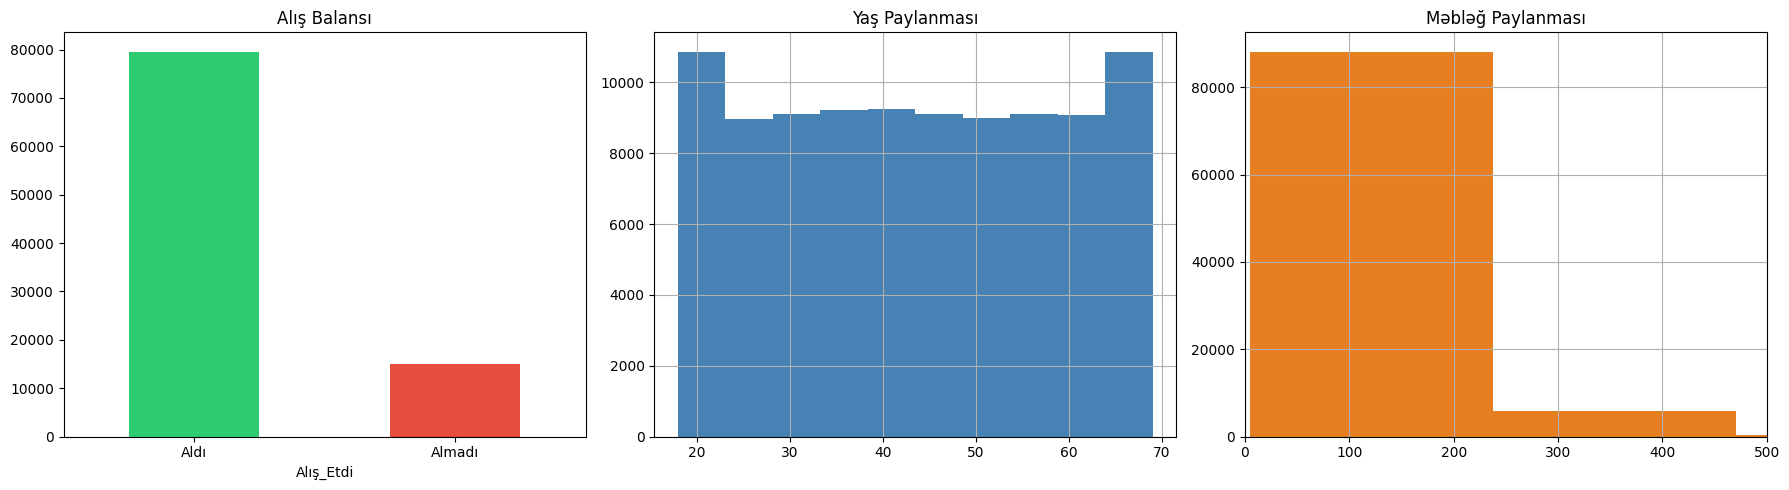

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Alış_Etdi'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Alış Balansı')
axes[0].set_xticklabels(['Aldı', 'Almadı'], rotation=0)

df['Yaş'].hist(bins=10, ax=axes[1], color='steelblue')
axes[1].set_title('Yaş Paylanması')

df['Məbləğ_AZN'].hist(bins=30, ax=axes[2], color='#e67e22')
axes[2].set_xlim(0, 500)
axes[2].set_title('Məbləğ Paylanması')
plt.tight_layout()
plt.show()

# fit_resample — X_train-ə baxır az olan sinif üçün yeni nümunələr yaradır və əlavə edir.

# .squeeze() = 2D-ni 1D-yə çevirir

# indi balanslaşdırdıq

# Az olan sinfi ("Almadı") çox olan sinifin ("Aldı") 50%-nə çatdırır sampling_strategy

In [30]:
smote = SMOTE(random_state=42,sampling_strategy=0.5)
X_train_balance , y_train_balance = smote.fit_resample(X_train, y_train)
y_train_balance = y_train_balance.squeeze()
print(y_train_balance.value_counts())

Alış_Etdi
1    63663
0    31831
Name: count, dtype: int64


# Overfitting var ona görə gridsearchcv ile hell edecem

In [31]:
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train_balance, y_train_balance)

y_pred_train = dt_overfit.predict(X_train_balance)
y_pred_test  = dt_overfit.predict(X_test)

train_accuracy = accuracy_score(y_true=y_train_balance, y_pred=y_pred_train)
test_accuracy  = accuracy_score(y_true=y_test,y_pred=y_pred_test)

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test  Accuracy: {test_accuracy:.2f}")
print(f"Fərq:{train_accuracy-test_accuracy:.2f}")


Train Accuracy: 1.00
Test  Accuracy: 0.81
Fərq:0.19


In [32]:
param_grid = {
    'max_depth': range(3,8),
    'min_samples_split': range(2,21,3),
    'min_samples_leaf': range(1,11,2),
    'criterion':['gini' , 'entropy'],
    'class_weight':['balanced', None]
}
GR = GridSearchCV(DecisionTreeClassifier(random_state=42) , param_grid=param_grid , cv=5 , n_jobs=-1 ,scoring='f1_macro' , verbose=1)

GR.fit(X_train_balance , y_train_balance)

print(f"Ən yaxşı parametrlər: {GR.best_params_}")

best_dt = GR.best_estimator_
train_acc = accuracy_score(y_true=y_train_balance,y_pred=best_dt.predict(X_train_balance))
test_acc = accuracy_score(y_true=y_test , y_pred=best_dt.predict(X_test))
print(f"Train: {train_acc:.2f}")
print(f"Test:  {test_acc:.2f}")
print(f"Fərq:  {train_acc-test_acc:.2f}")

Fitting 5 folds for each of 700 candidates, totalling 3500 fits
Ən yaxşı parametrlər: {'class_weight': None, 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Train: 0.85
Test:  0.85
Fərq:  -0.00


In [33]:
y_pred = best_dt.predict(X_test)
print(classification_report(y_test , y_pred , 
    target_names = ['Almadı' , 'Aldı']))

              precision    recall  f1-score   support

      Almadı       0.53      0.71      0.61      3002
        Aldı       0.94      0.88      0.91     15916

    accuracy                           0.85     18918
   macro avg       0.74      0.79      0.76     18918
weighted avg       0.88      0.85      0.86     18918



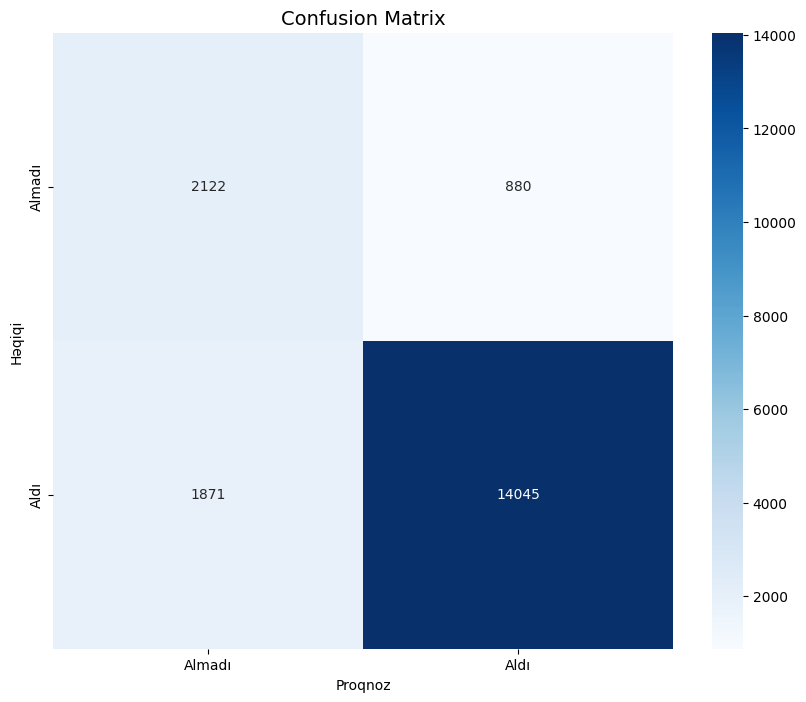

In [34]:
cm = confusion_matrix(y_true=y_test , y_pred=y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Almadı', 'Aldı'],
            yticklabels=['Almadı', 'Aldı'],
            cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Həqiqi')
plt.xlabel('Proqnoz')
plt.show()

# tesadüfi paylanma olmayıb

In [35]:
cross_valdition = cross_val_score(best_dt , X_train_balance , y_train_balance , cv=5 , scoring='f1')
print(f"Cross Val F1: {cross_valdition}")
print(f"Ortalama F1: {cross_valdition.mean():.2f}")

Cross Val F1: [0.86550067 0.87120003 0.89419768 0.89283282 0.8974878 ]
Ortalama F1: 0.88


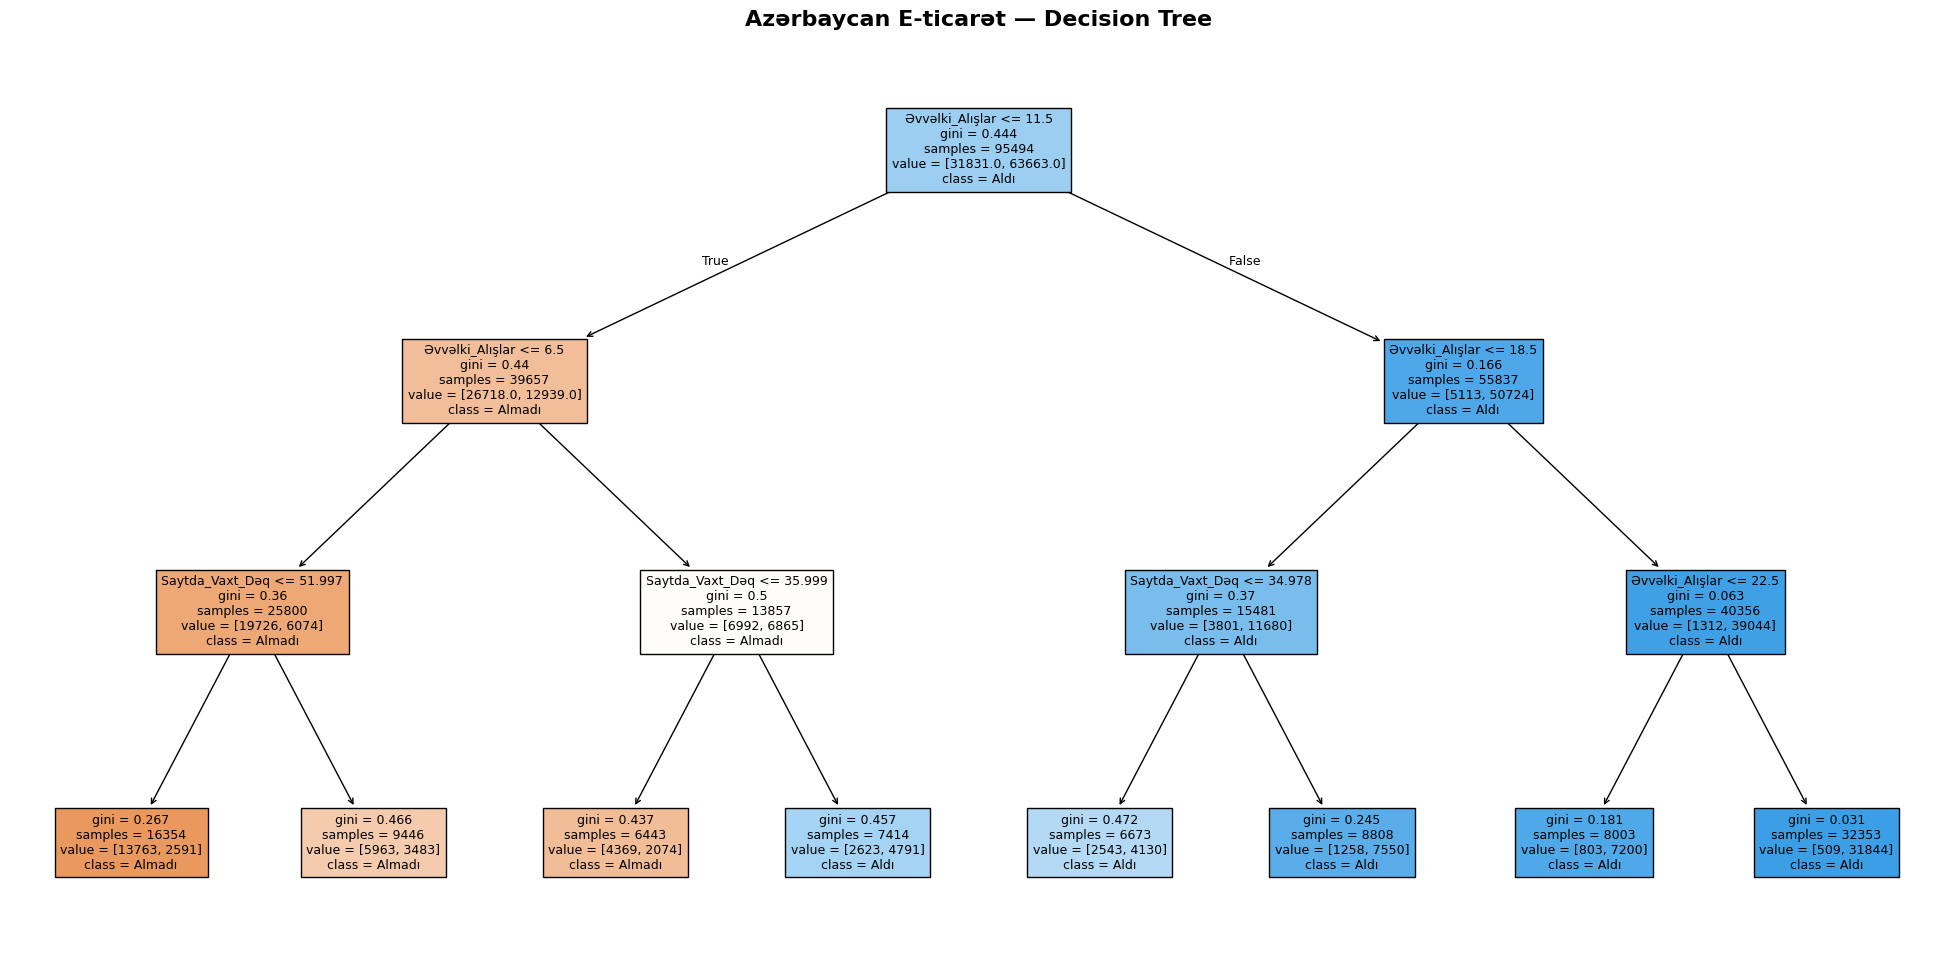

In [36]:
dt_visual = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_leaf= 1,
    min_samples_split=2,
    random_state=42
)
dt_visual.fit(X_train_balance, y_train_balance)

plt.figure(figsize=(25,12))
feature_names = X.columns.tolist()
plot_tree(
    dt_visual,
    filled=True,
    feature_names=feature_names,
    class_names=['Almadı', 'Aldı'],
    fontsize=9,
    rounded=False
    )
plt.title('Azərbaycan E-ticarət — Decision Tree', fontsize=16, fontweight='bold')
plt.show()

In [37]:
df

,Yaş,Şəhər,Kateqoriya,Üzvlük_Növü,Ödəniş_Üsulu,Trafik_Mənbəyi,Məbləğ_AZN,Əvvəlki_Alışlar,Müştəri_Rəyi,Saytda_Vaxt_Dəq,Alış_Etdi
0,56,3,1,1,1,4,130.160000,2,5,45.0,0
1,69,7,4,2,1,1,82.870000,13,4,56.0,1
2,32,1,7,0,2,4,103.920000,0,4,18.0,0
3,60,1,3,0,2,4,11.340000,9,3,48.0,1
4,25,2,1,0,2,4,6.990000,1,4,18.0,0
...,...,...,...,...,...,...,...,...,...,...,...
94581,33,7,1,0,1,3,56.080000,33,4,76.0,1
94582,57,7,3,3,3,4,264.820000,15,5,17.0,1
94583,20,1,1,3,3,0,28.200000,24,4,20.0,1
94584,67,1,6,3,1,3,23.980000,32,5,26.0,1


# ən yüksək dəyər daha önəmlidir

In [38]:
best_dt.feature_importances_

array([0.00147434, 0.00124585, 0.001867  , 0.00258247, 0.00788933,
       0.00418136, 0.00448692, 0.81089393, 0.06913084, 0.09624797])

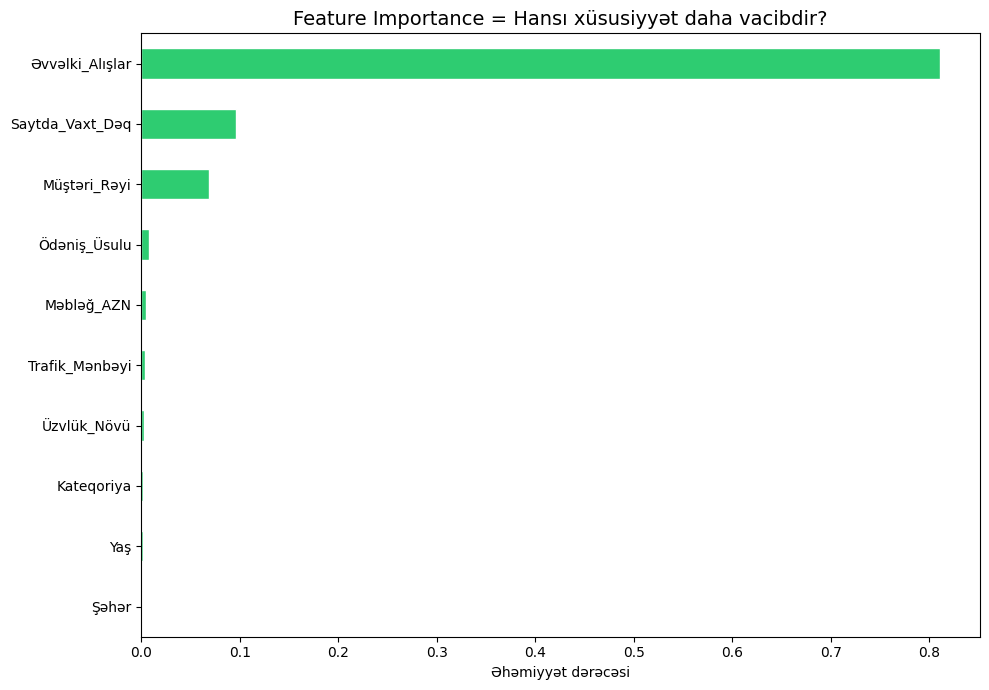

Ən vacib 3 xüsusiyyət:
Müştəri_Rəyi       0.069131
Saytda_Vaxt_Dəq    0.096248
Əvvəlki_Alışlar    0.810894
dtype: float64


In [39]:
importance = pd.Series(best_dt.feature_importances_  , index = X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 7))
importance.plot(kind='barh', color='#2ecc71', edgecolor='white')
plt.title('Feature Importance = Hansı xüsusiyyət daha vacibdir?', fontsize=14)
plt.xlabel('Əhəmiyyət dərəcəsi')
plt.tight_layout()
plt.show()

print("Ən vacib 3 xüsusiyyət:")
print(importance.tail(3))

In [40]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.2f}")
print(f"\nƏn yaxşı parametrlər:")
for k, v in GR.best_params_.items():
    print(f"  {k}: {v}")

Accuracy:  0.85
Precision: 0.94
Recall:    0.88
F1 Score:  0.91

Ən yaxşı parametrlər:
  class_weight: None
  criterion: gini
  max_depth: 7
  min_samples_leaf: 1
  min_samples_split: 2


# NƏTİCƏ

In [41]:
yeni_musteri = pd.DataFrame({
    'Yaş':              [28],
    'Şəhər':            [2],
    'Kateqoriya':       [3],
    'Üzvlük_Növü':      [1],
    'Ödəniş_Üsulu':     [0],
    'Trafik_Mənbəyi':   [1],
    'Məbləğ_AZN':       [150.0],
    'Əvvəlki_Alışlar':  [5],
    'Müştəri_Rəyi':     [4],
    'Saytda_Vaxt_Dəq':  [25.0]
})

proqnoz = best_dt.predict(yeni_musteri)

ehtimal = best_dt.predict_proba(yeni_musteri)


if proqnoz[0] == 1:
    print("Bu müştəri ALACAQ")
else:
    print("Bu müştəri ALMAYACAQ")

print(f"Almama ehtimalı: %{ehtimal[0][0]*100:.1f}")
print(f"Alma ehtimalı:   %{ehtimal[0][1]*100:.1f}")

Bu müştəri ALMAYACAQ
Almama ehtimalı: %93.9
Alma ehtimalı:   %6.1


In [ ]:
import pickle
import os
os.makedirs('model' , exist_ok=True)
with open('model/decision_tree.pkl', 'wb') as f:
    pickle.dump(best_dt, f)

✅ Model saxlanıldı!
